In [1]:
import pandas as pd

data = pd.read_csv('output/wucaishen_enriched_output_2401.csv')
data.head()


,row_id,productid,loginname,billno,billtime,account,cus_account,currency,slottype,basepoint,...,result_pos14,result_pos15,streak,win_streak,lose_streak,is_split,group_index,row_number_in_block,sub_index,group_id
0,17180053620,BQ1,BQ1BBIN936408076,8240127031116932,2024-01-26T22:53:06.000Z,0.5,0.3,CNY,1.0,222.36,...,10,11,31,1,0,0,0,71338,1783,BQ1BBIN936408076_0_1783
1,17180053621,BQ1,BQ1BBIN936408076,8240127031117496,2024-01-26T22:53:11.000Z,0.5,-0.5,CNY,1.0,222.66,...,201,2,32,0,1,0,0,71339,1783,BQ1BBIN936408076_0_1783
2,17180053622,BQ1,BQ1BBIN936408076,8240127031117817,2024-01-26T22:53:13.000Z,0.5,-0.3,CNY,1.0,222.16,...,5,7,33,0,2,0,0,71340,1783,BQ1BBIN936408076_0_1783
3,17180053623,BQ1,BQ1BBIN936408076,8240127031118389,2024-01-26T22:53:18.000Z,0.5,-0.5,CNY,1.0,221.86,...,11,8,34,0,3,0,0,71341,1783,BQ1BBIN936408076_0_1783
4,17180053624,BQ1,BQ1BBIN936408076,8240127031118712,2024-01-26T22:53:20.000Z,0.5,-0.5,CNY,1.0,221.36,...,11,7,35,0,4,0,0,71342,1783,BQ1BBIN936408076_0_1783


In [ ]:
data.columns.tolist()

## Variable description:
- basepoint: 下注/结算前余额
- account: 单次投注额
- cus_account: 单笔净利润
- payout: 单次投注收入（account + cus_account）
- delta_t: 相对于上次投注的时间
- delta_bet:
- delta_profit:
- delta_payout:
- streak: 连续投注次数（<20s)
- win_streak:
- lose_streak
- rtp:

In [ ]:
import glob
from bituslabs_ds.eda import read_csv_cols

files = glob.glob(f'./output/wucaishen_enriched_output_24??.csv')
print(files)
sampling = 2_000_000
data = read_csv_cols(
    files,
    columns = ['group_id', 'billtime', 'basepoint', 'account', 'cus_account', 'payout', 'delta_t', 'delta_bet', 'delta_profit', 'delta_payout','streak', 'win_streak', 'lose_streak', 'rtp'],
    filters={'currency': 'CNY'},
    sampling=sampling
)

data['billtime'] = pd.to_datetime(data['billtime'])
data['bill_day'] = data['billtime'].dt.date
data = data.drop(columns='billtime').groupby(['group_id', 'bill_day']).mean().reset_index()
data.drop(columns='group_id').to_csv(f'./output/wucaishen_enriched_output_24_group_mean_{sampling}.csv', index=False)

In [1]:
import pandas as pd
data = pd.read_csv('./output/wucaishen_enriched_output_24_group_mean_2000000.csv')

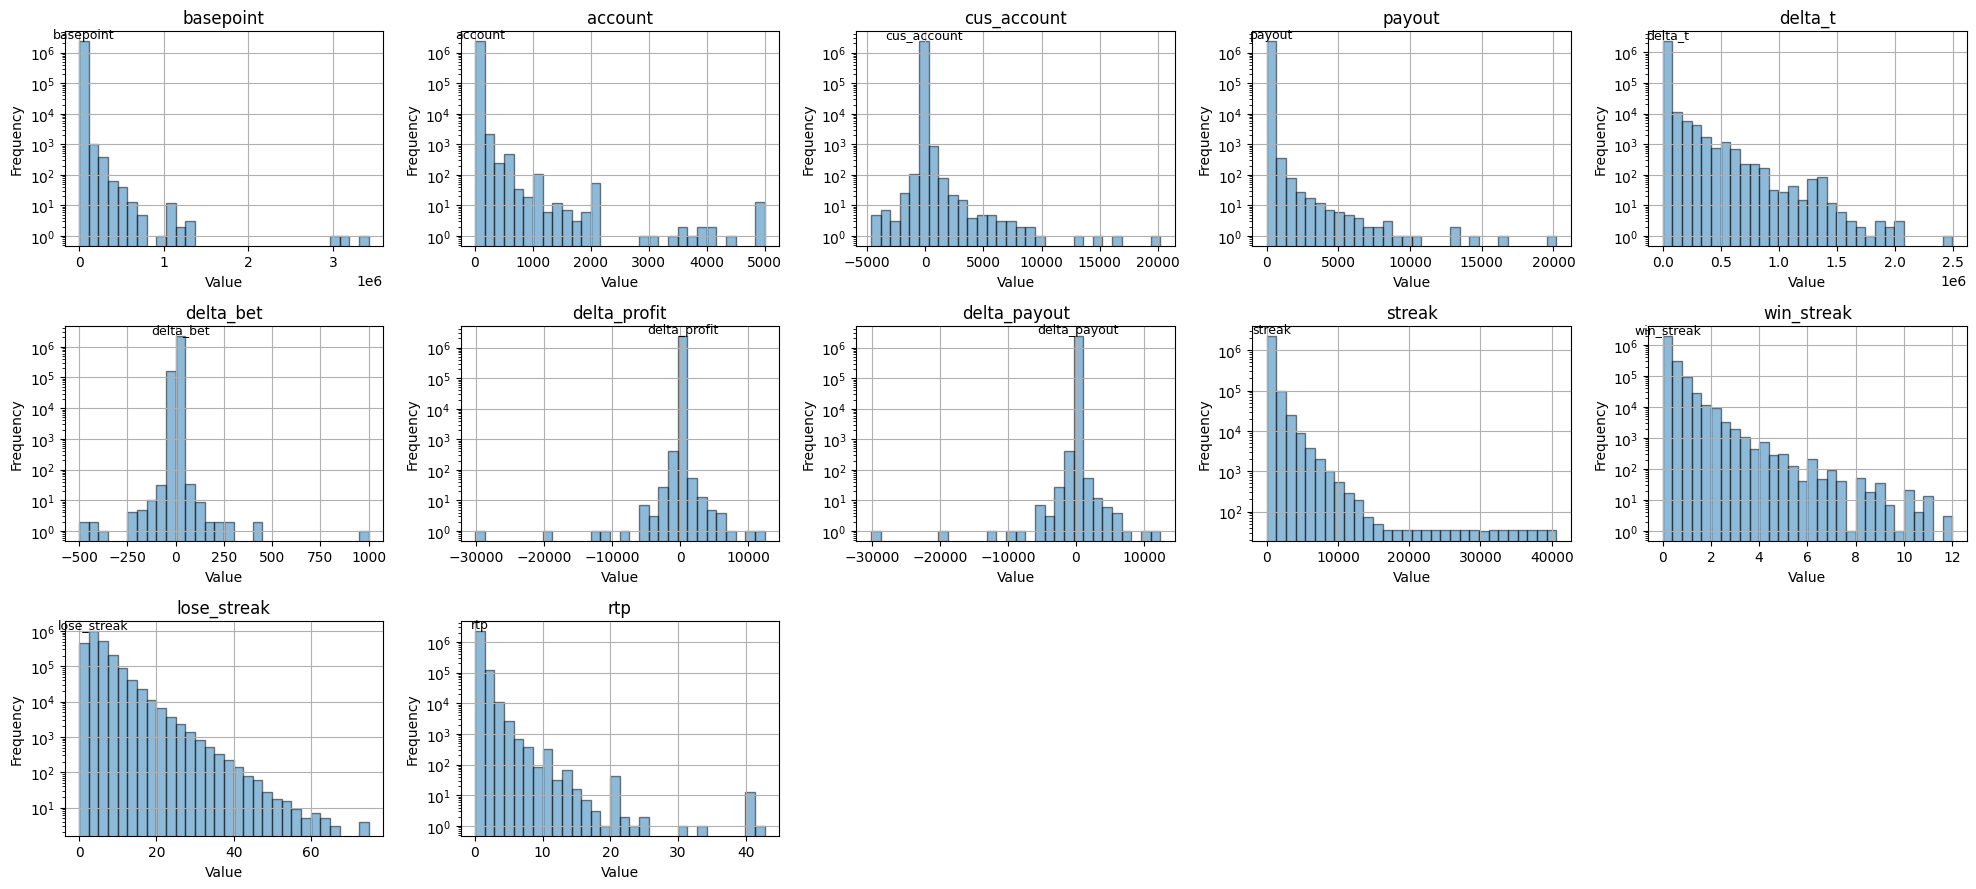

In [40]:

from bituslabs_ds.eda import plot_df_distribution
plot_df_distribution(data.iloc[:, 1:], log=True)


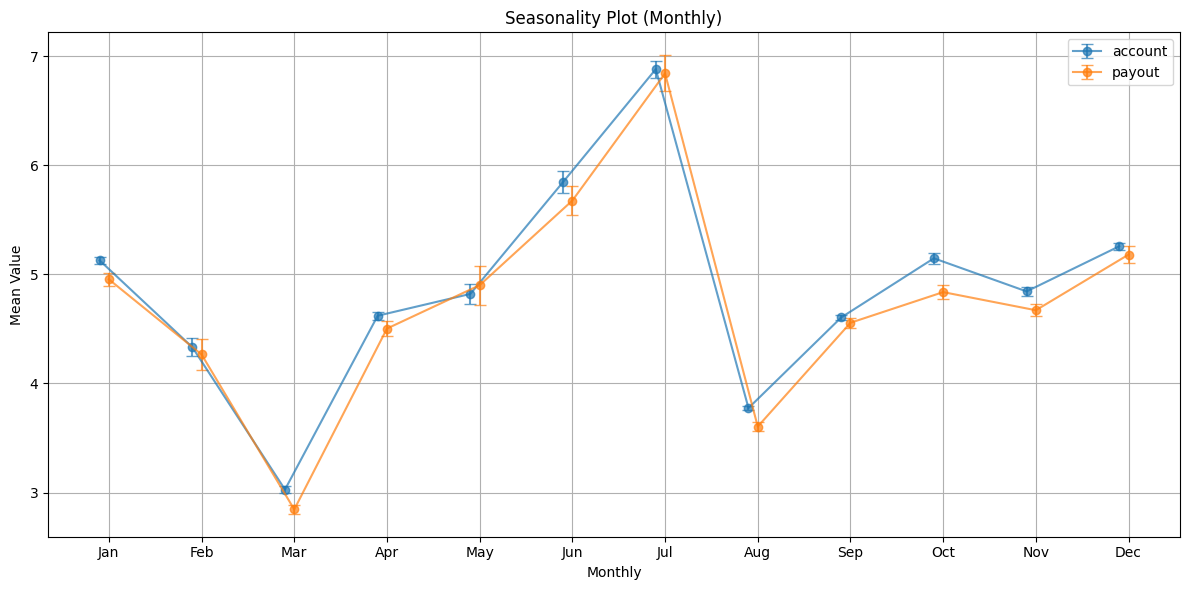

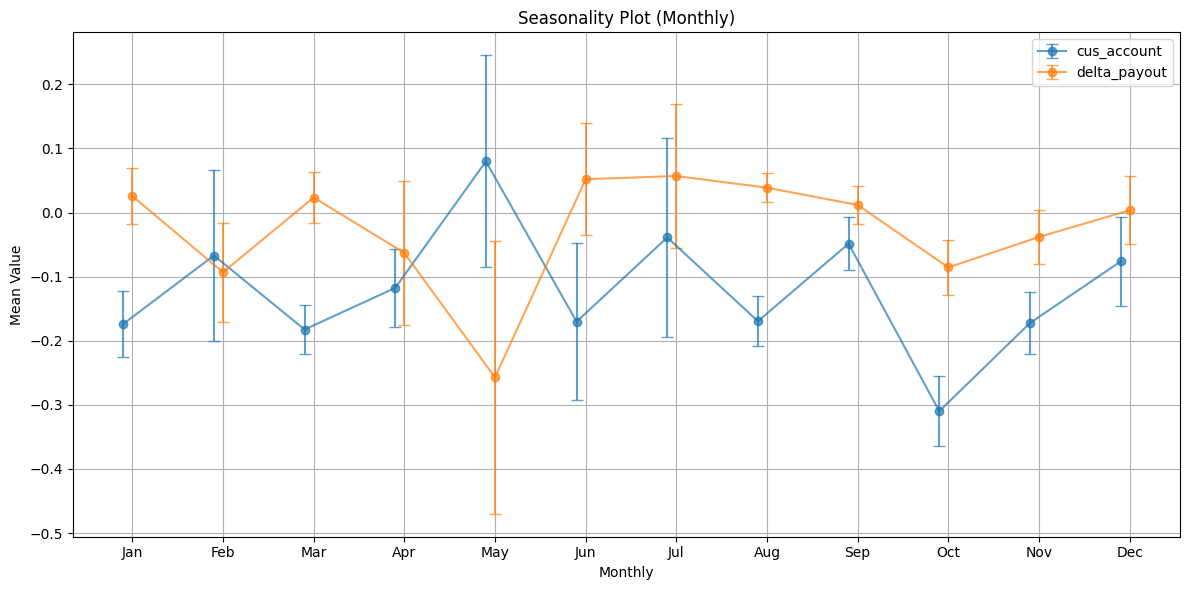

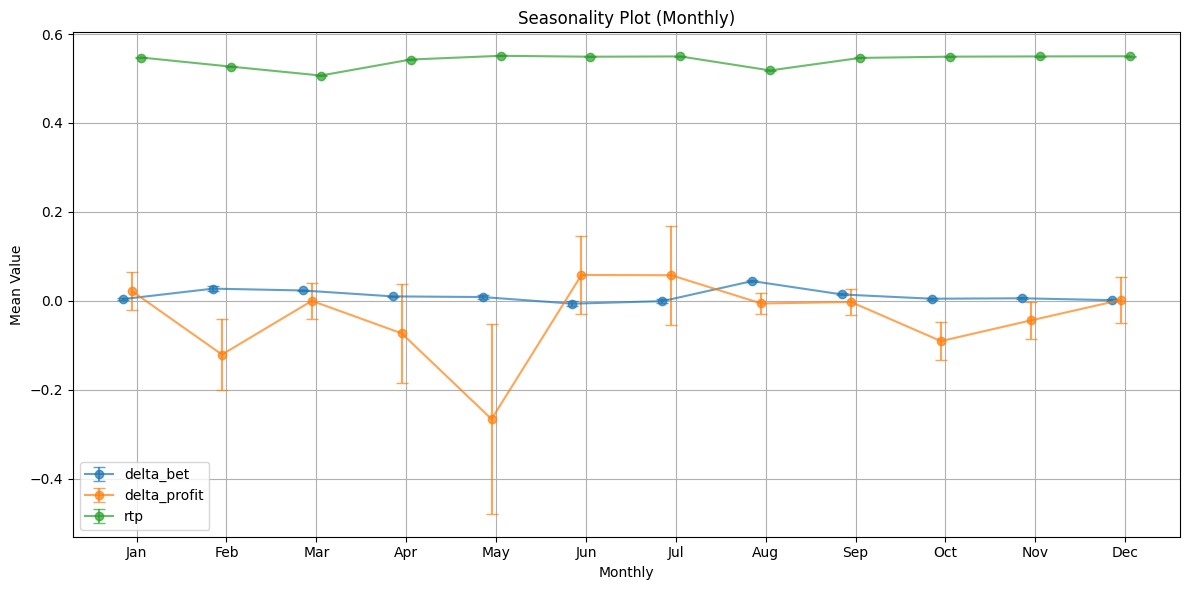

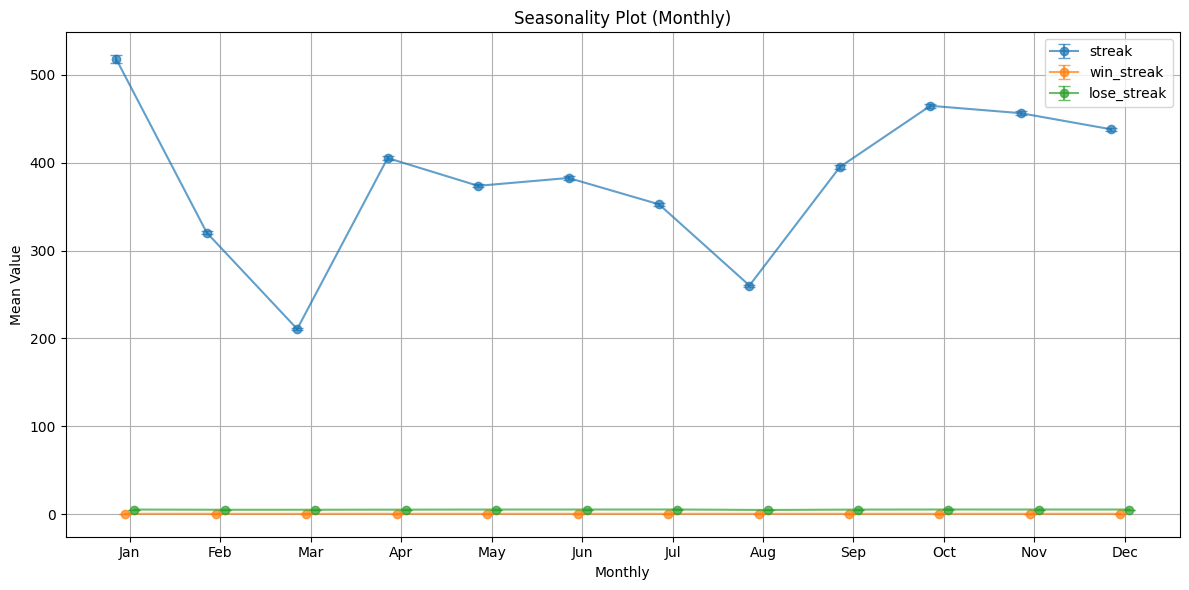

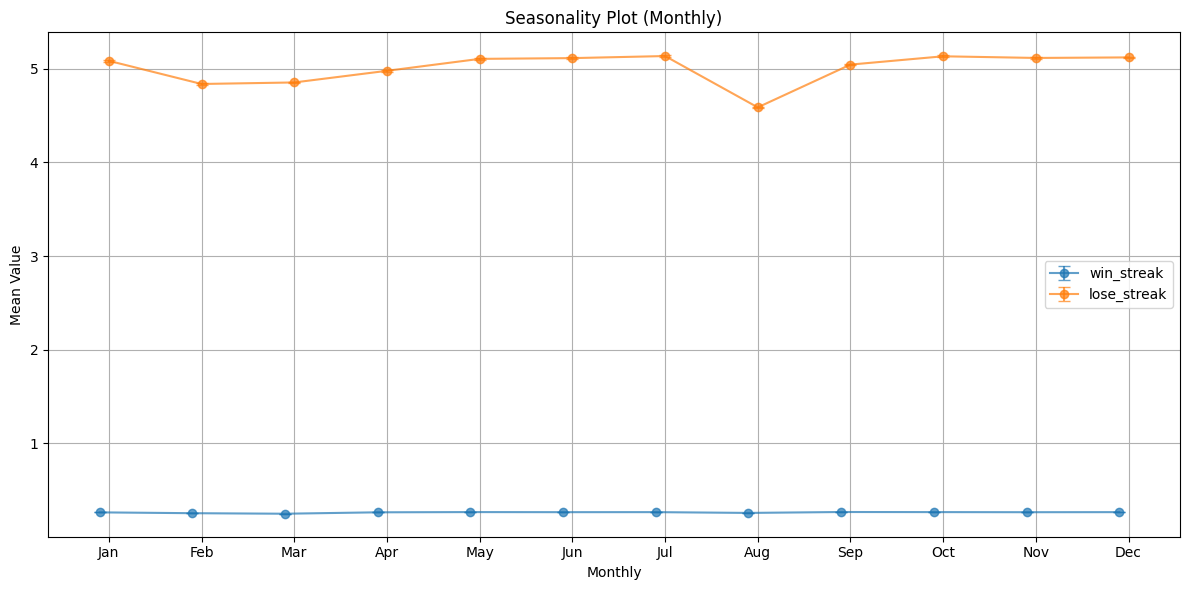

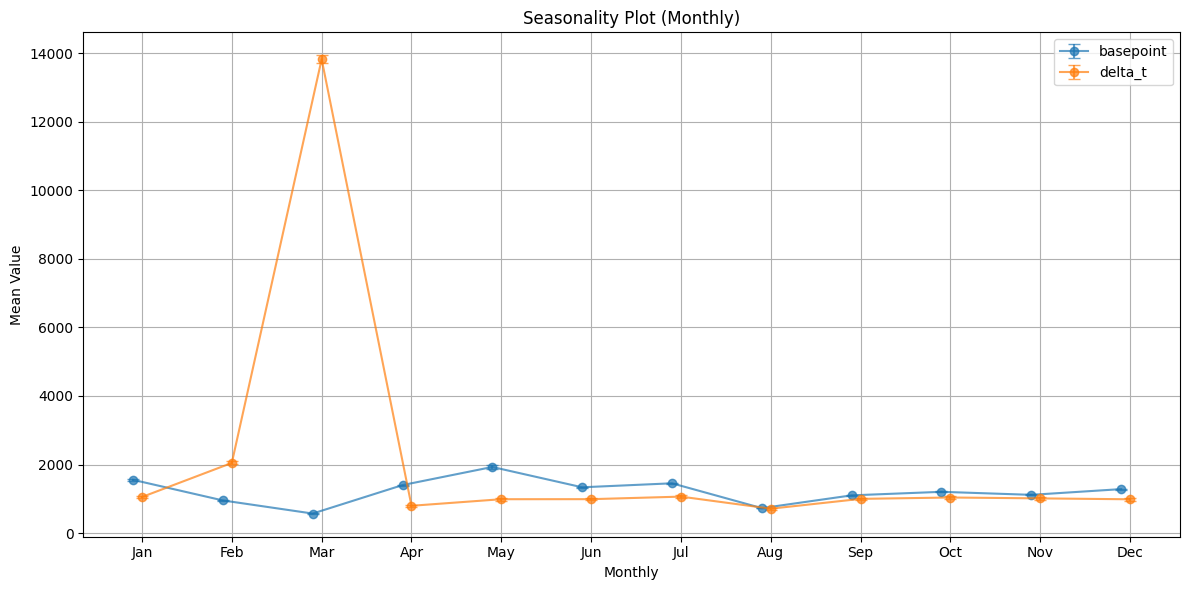

In [2]:

from bituslabs_ds.eda import plot_seasonality

plot_seasonality(data['bill_day'], data[['account', 'payout']])
plot_seasonality(data['bill_day'], data[['cus_account', 'delta_payout']])
plot_seasonality(data['bill_day'], data[['delta_bet', 'delta_profit', 'rtp']])
plot_seasonality(data['bill_day'], data[['streak', 'win_streak', 'lose_streak']])
plot_seasonality(data['bill_day'], data[['win_streak', 'lose_streak']])
plot_seasonality(data['bill_day'], data[['basepoint', 'delta_t']])

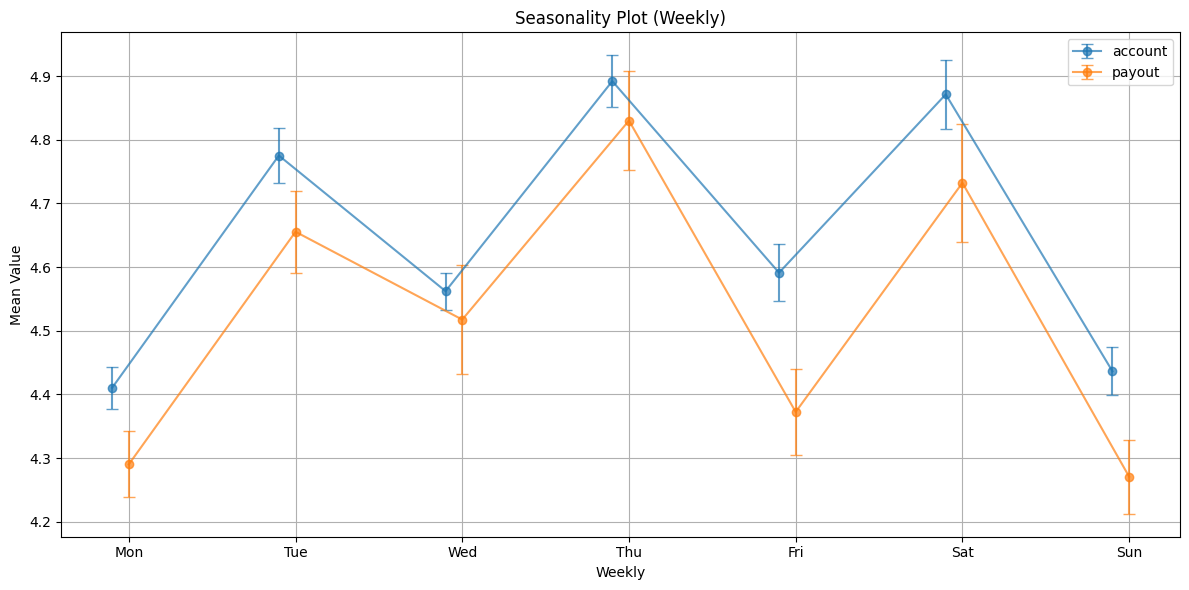

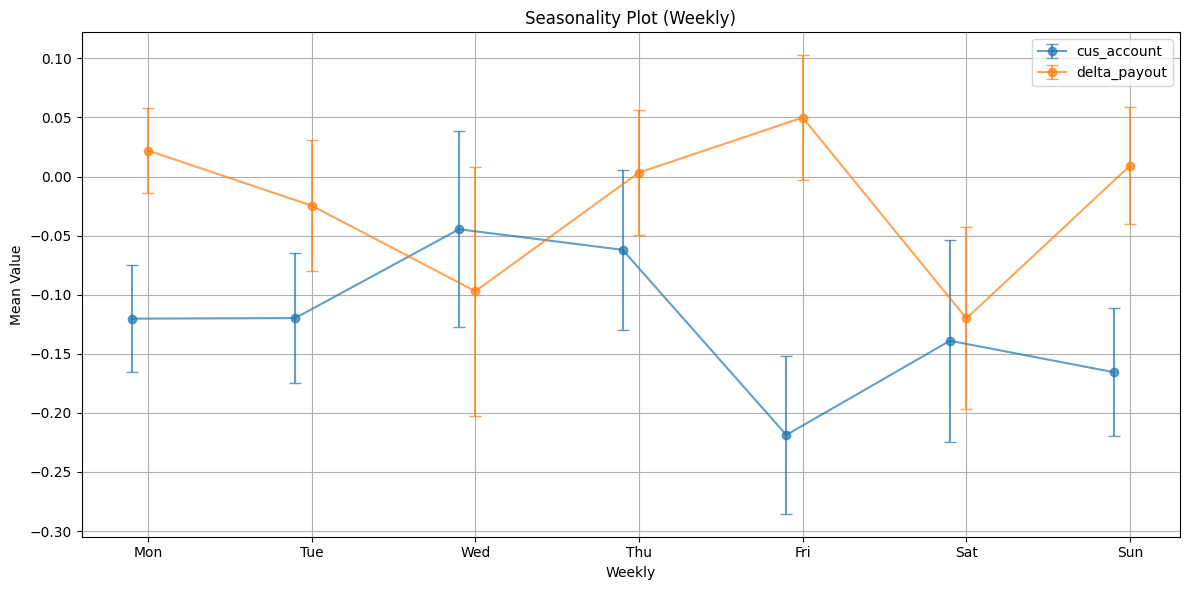

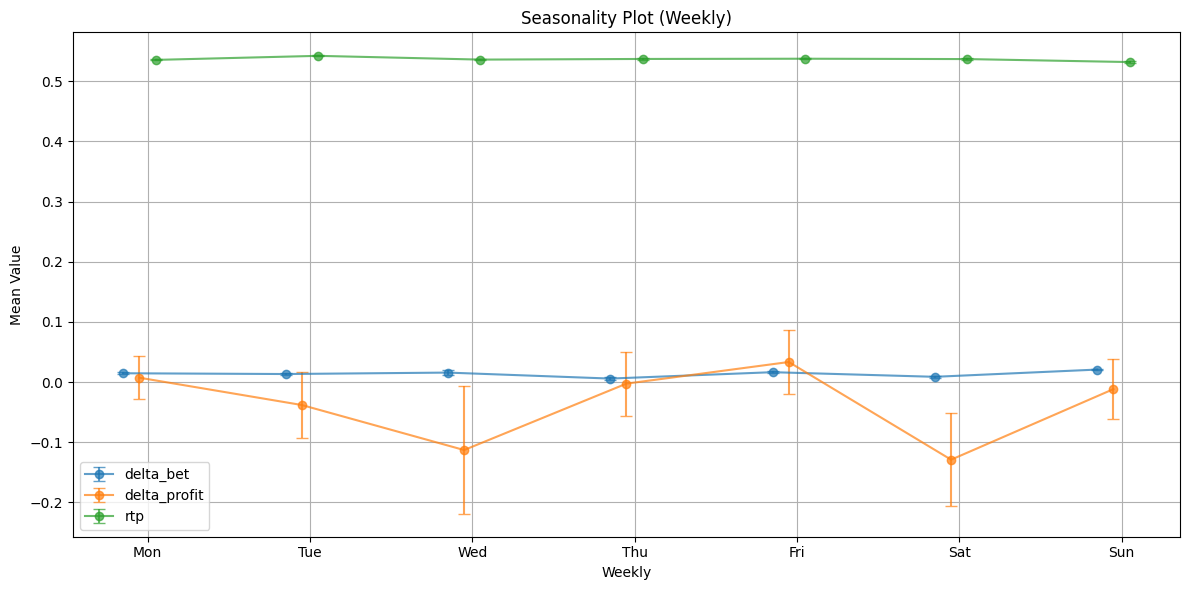

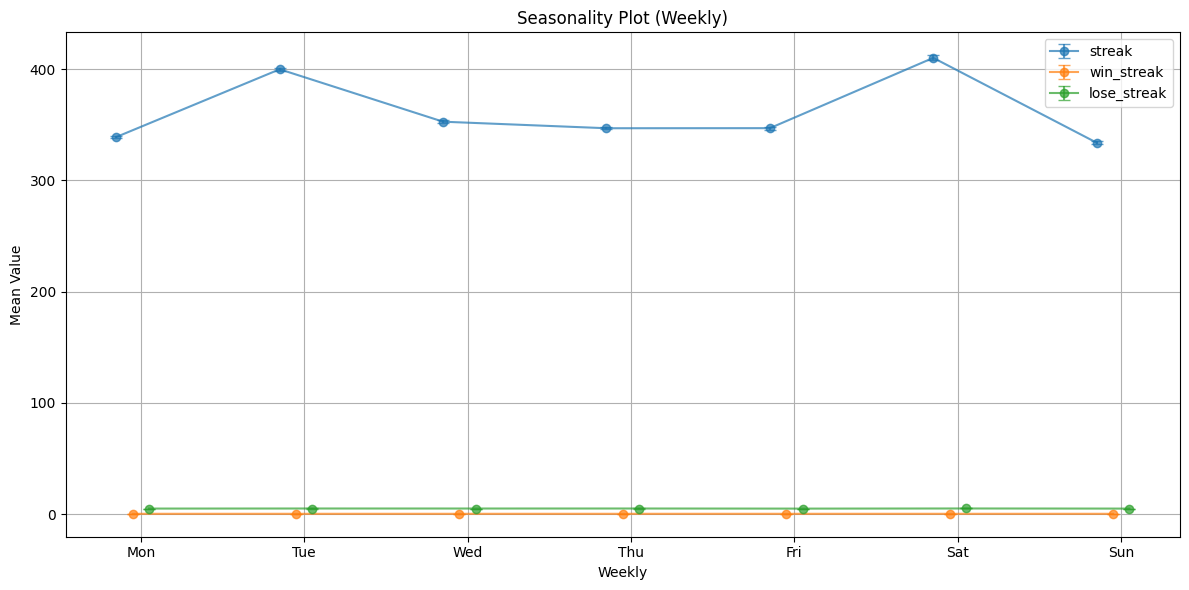

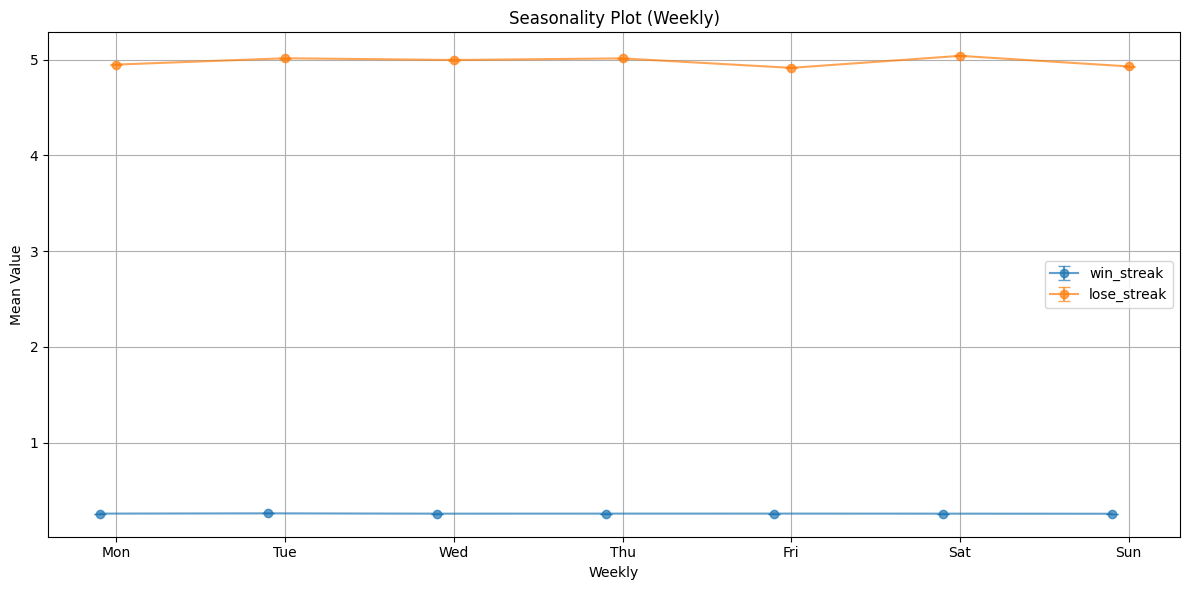

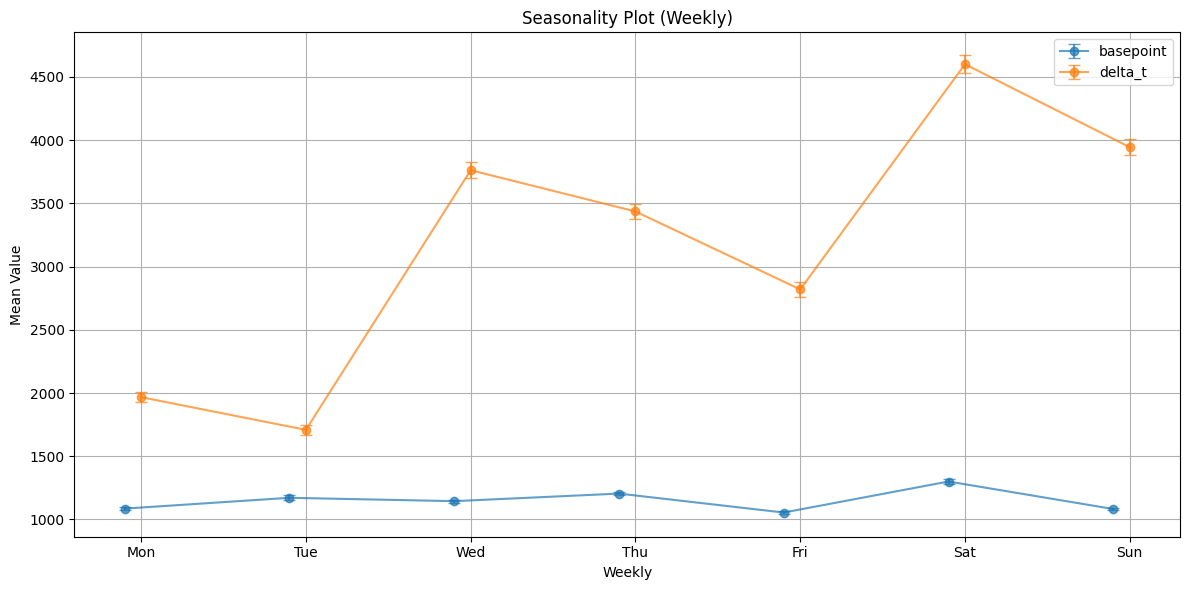

In [3]:

plot_seasonality(data['bill_day'], data[['account', 'payout']], freq='weekly')
plot_seasonality(data['bill_day'], data[['cus_account', 'delta_payout']], freq='weekly')
plot_seasonality(data['bill_day'], data[['delta_bet', 'delta_profit', 'rtp']], freq='weekly')
plot_seasonality(data['bill_day'], data[['streak', 'win_streak', 'lose_streak']], freq='weekly')
plot_seasonality(data['bill_day'], data[['win_streak', 'lose_streak']], freq='weekly')
plot_seasonality(data['bill_day'], data[['basepoint', 'delta_t']], freq='weekly')

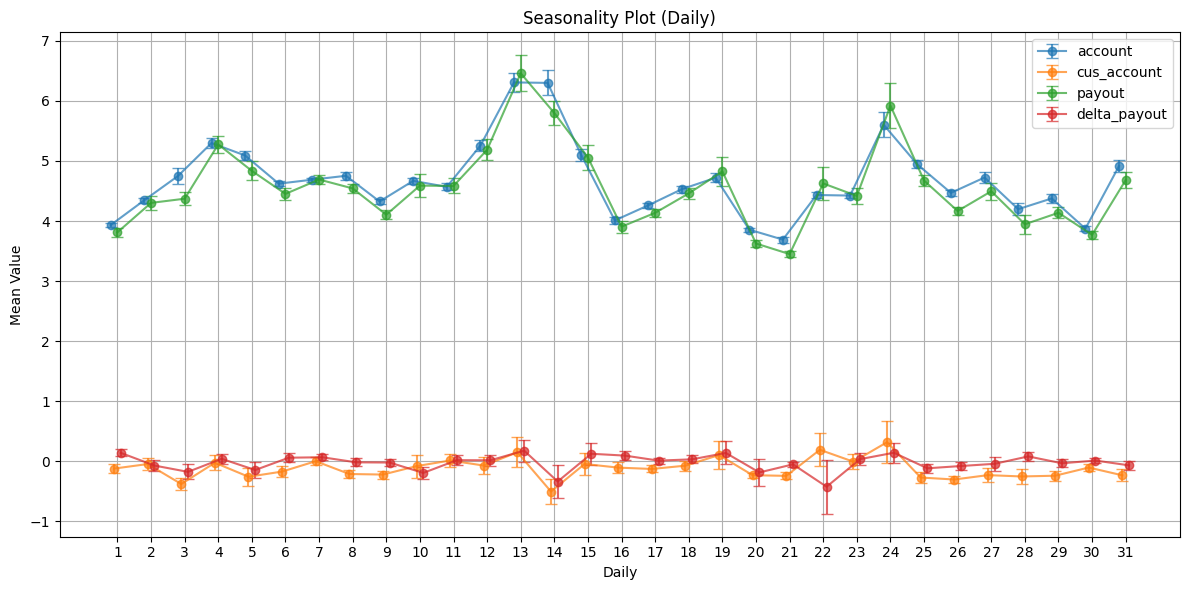

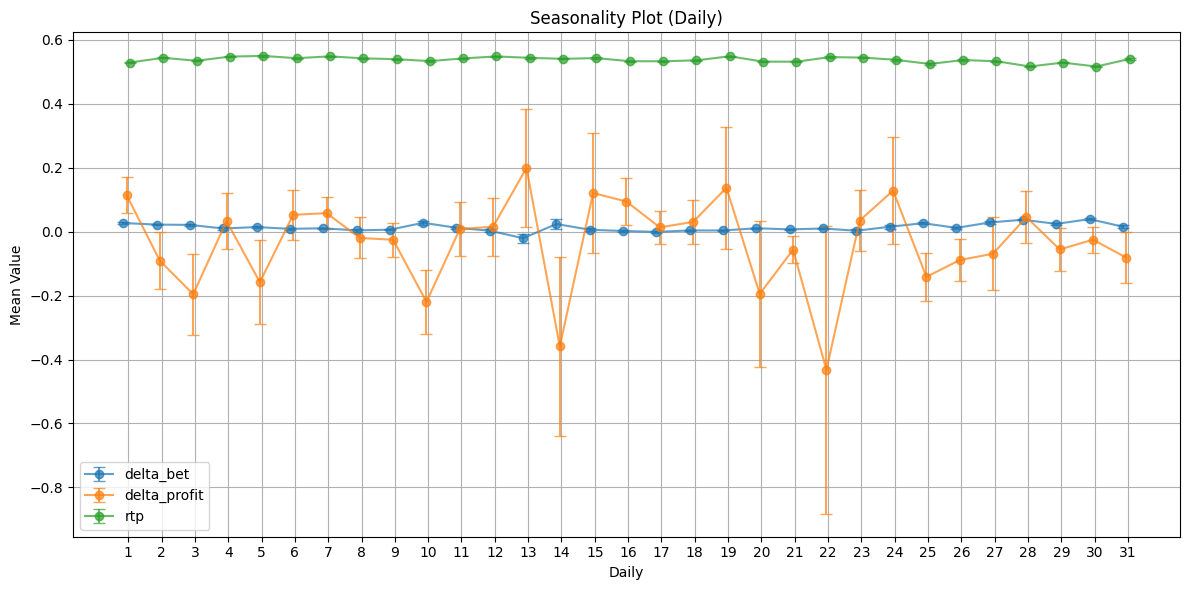

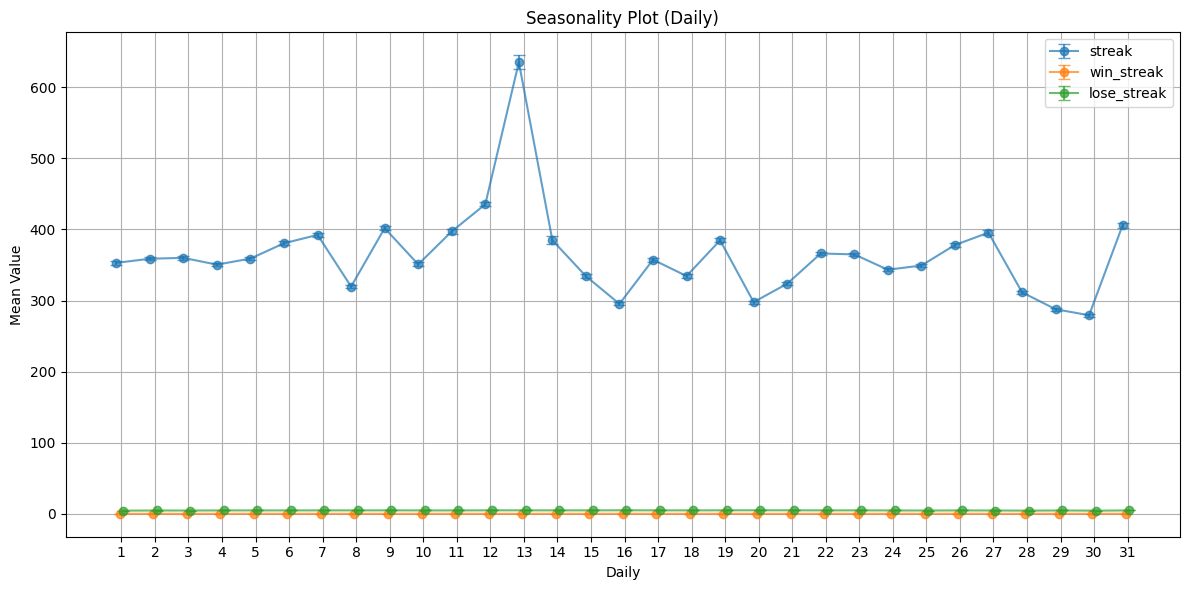

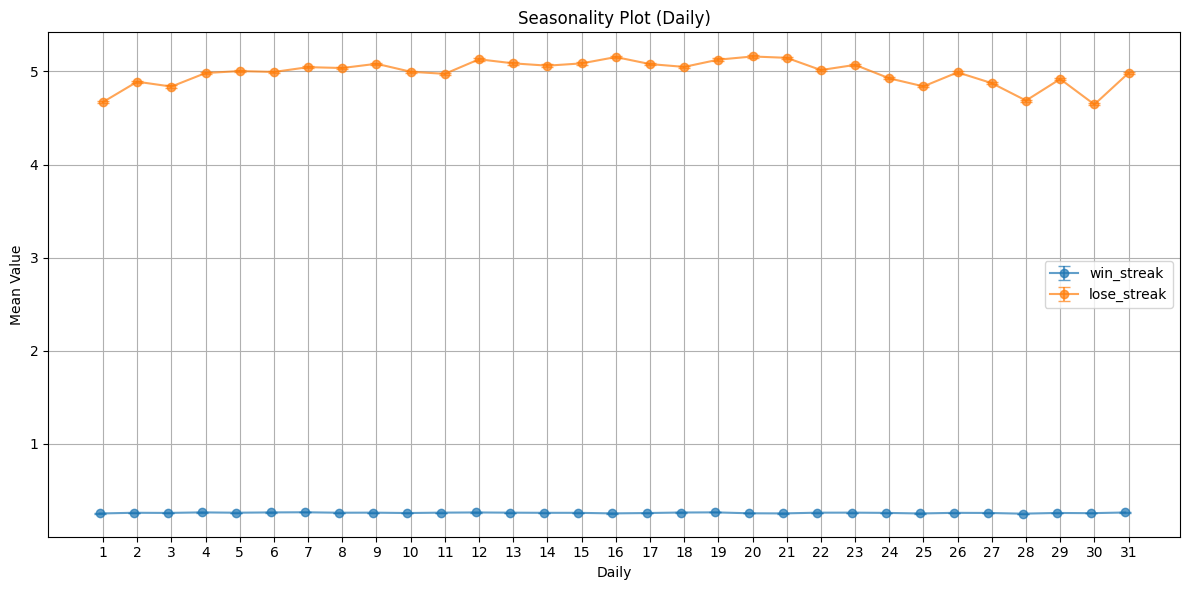

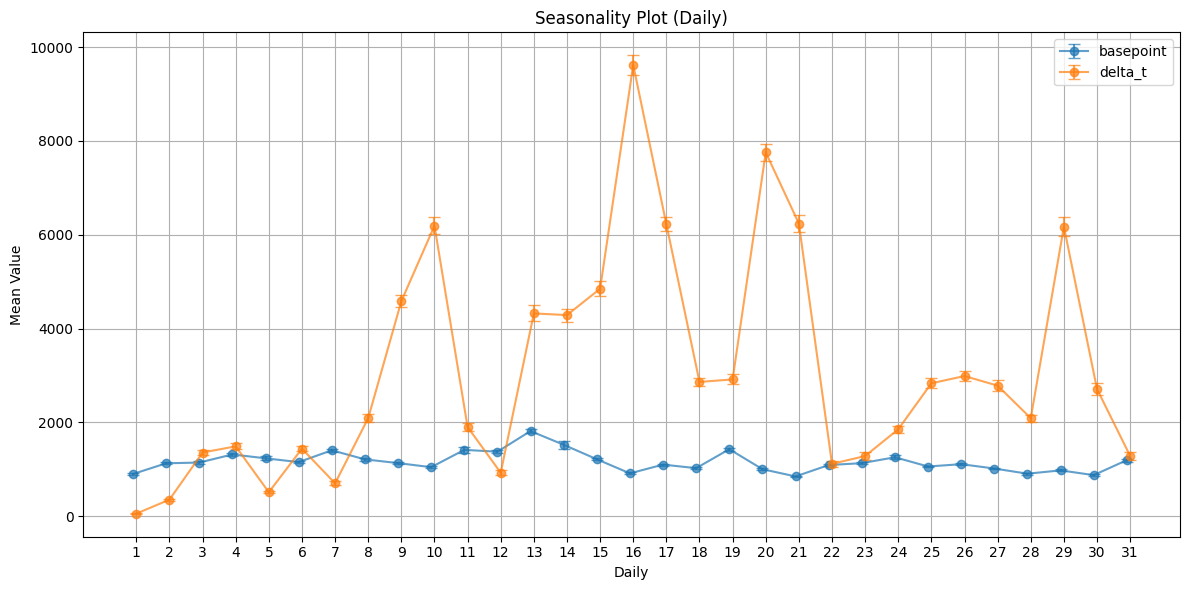

In [4]:
plot_seasonality(data['bill_day'], data[['account', 'cus_account', 'payout', 'delta_payout']], freq='daily')
plot_seasonality(data['bill_day'], data[['delta_bet', 'delta_profit', 'rtp']], freq='daily')
plot_seasonality(data['bill_day'], data[['streak', 'win_streak', 'lose_streak']], freq='daily')
plot_seasonality(data['bill_day'], data[['win_streak', 'lose_streak']], freq='daily')
plot_seasonality(data['bill_day'], data[['basepoint', 'delta_t']], freq='daily')

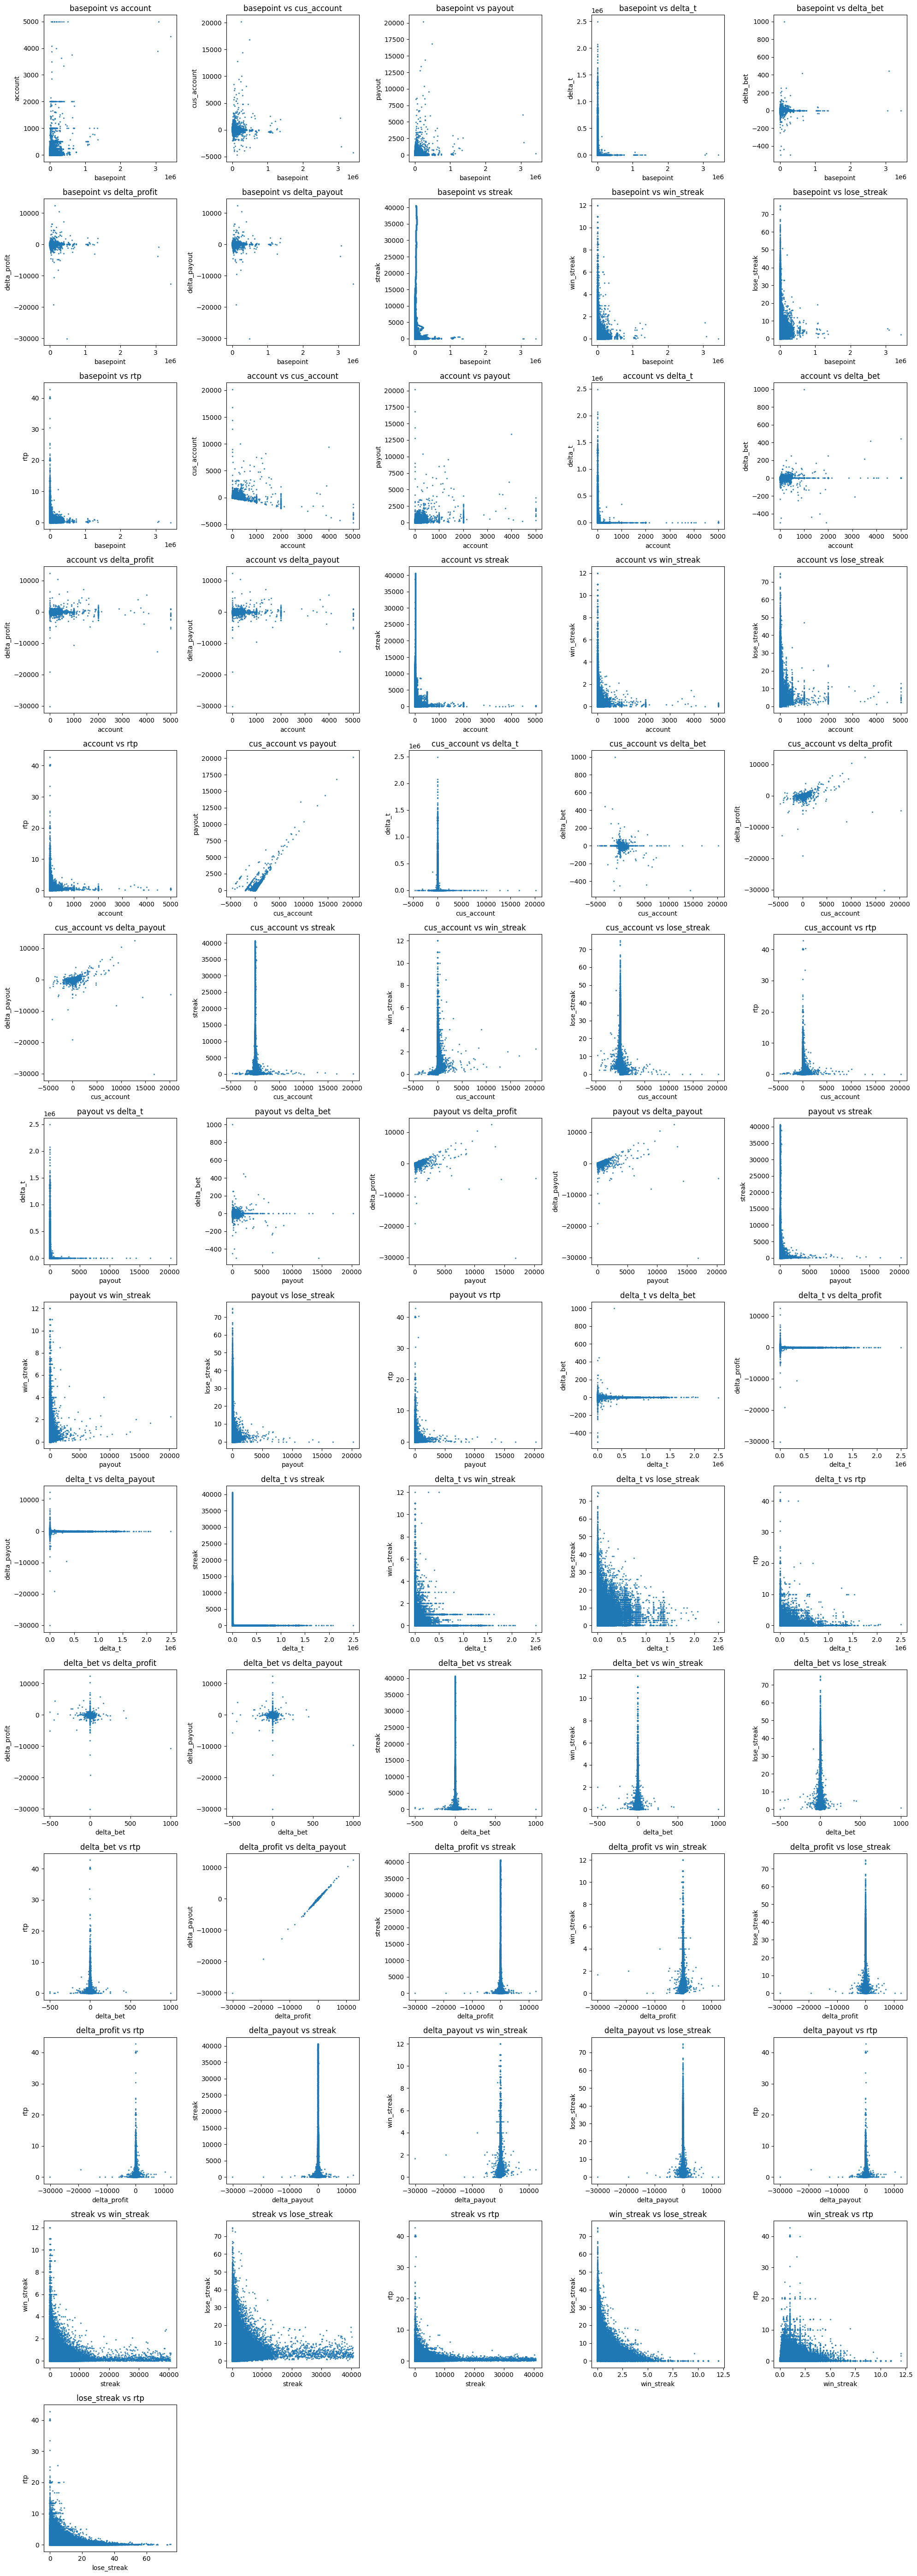

In [7]:
from bituslabs_ds.eda import plot_scatter_pairs

plot_scatter_pairs(data.iloc[:, 1:])